# ETL Pipeline: LA Retail Sales Data

1. Extract - read the raw CSV + Excel files
2. Transform - clean and prepare the data
3. Load - save into PostgreSQL
4. Report - read it back and generate a summary + charts

In [25]:
# Import all the libraries we need for this notebook
import pandas as pd
import matplotlib.pyplot as plt
import os
from dotenv import load_dotenv
from sqlalchemy import create_engine

In [26]:
# Load database settings from the .env file 
load_dotenv()

db_host = os.getenv("DB_HOST")
db_port = os.getenv("DB_PORT")
db_name = os.getenv("DB_NAME")
db_user = os.getenv("DB_USER")
db_password = os.getenv("DB_PASSWORD")

# The "engine" is what pandas and SQLAlchemy use to talk to PostgreSQL
connection_string = f"postgresql+psycopg2://{db_user}:{db_password}@{db_host}:{db_port}/{db_name}"
engine = create_engine(connection_string)

print("Database engine ready")

Database engine ready


---
## Step 1: Extract

We have two raw files, like two POS export batches from the same store chain:
- `data/raw/sales_sept_1_15.csv` (first half of September, CSV export)
- `data/raw/sales_sept_16_30.xlsx` (second half of September, Excel export)

In [27]:
# Read the CSV file
csv_data = pd.read_csv("../data/raw/sales_sept_1_15.csv")
print(f"Extracted {len(csv_data)} rows from CSV")
csv_data.head()

Extracted 357 rows from CSV


,store_id,store_name,product_category,date,Unit sales,DOLLAR SALES,store_zip,promotion_flag
0,LA002,Store_2,Household,9/1/24,16.0,96.28,90004,True
1,LA001,Store_1,Beverages,9/1/24,14.0,86.63,90004,True
2,LA004,Store_4,Produce,9/15/24,18.0,298.26,90003,True
3,LA003,Store_3,Household,9/7/24,7.0,25.69,90001,True
4,LA005,Store_5,Household,9/15/24,11.0,95.30,90001,True


In [28]:
# Read the Excel file
excel_data = pd.read_excel("../data/raw/sales_sept_16_30.xlsx")
print(f"Extracted {len(excel_data)} rows from Excel")
excel_data.head()

Extracted 393 rows from Excel


,store_id,store_name,product_category,date,Unit sales,DOLLAR SALES,store_zip,promotion_flag
0,LA008,Store_8,Beverages,9/18/24,25.0,85.46,90005,False
1,LA004,Store_4,Beverages,9/23/24,3.0,41.71,90004,False
2,LA010,Store_10,Snacks,9/21/24,35.0,529.35,900XX,True
3,LA004,Store_4,Produce,9/30/24,46.0,352.55,90003,False
4,LA009,Store_9,Beverages,9/16/24,49.0,139.56,90005,True


In [29]:
# Combine both sources into one DataFrame
raw_data = pd.concat([csv_data, excel_data], ignore_index=True)
print(f"Combined total: {len(raw_data)} rows")
raw_data.head()

Combined total: 750 rows


,store_id,store_name,product_category,date,Unit sales,DOLLAR SALES,store_zip,promotion_flag
0,LA002,Store_2,Household,9/1/24,16.0,96.28,90004,True
1,LA001,Store_1,Beverages,9/1/24,14.0,86.63,90004,True
2,LA004,Store_4,Produce,9/15/24,18.0,298.26,90003,True
3,LA003,Store_3,Household,9/7/24,7.0,25.69,90001,True
4,LA005,Store_5,Household,9/15/24,11.0,95.30,90001,True



## Step 2: Transform



In [30]:
# Start with a copy so we always still have the original raw_data if needed
df = raw_data.copy()

# Rename messy column names to simple lowercase_with_underscores
df = df.rename(columns={
    "Unit sales": "unit_sales",
    "DOLLAR SALES": "dollar_sales",
})
df.columns

Index(['store_id', 'store_name', 'product_category', 'date', 'unit_sales',
       'dollar_sales', 'store_zip', 'promotion_flag'],
      dtype='str')

In [31]:
# Remove any exact duplicate rows
before = len(df)
df = df.drop_duplicates()
print(f"Removed {before - len(df)} duplicate rows")

Removed 0 duplicate rows


In [32]:
# Fill missing sales numbers with the column average
missing_units = df["unit_sales"].isna().sum()
missing_dollars = df["dollar_sales"].isna().sum()

avg_units = df["unit_sales"].mean()
avg_dollars = df["dollar_sales"].mean()

df["unit_sales"] = df["unit_sales"].fillna(round(avg_units))
df["dollar_sales"] = df["dollar_sales"].fillna(round(avg_dollars, 2))

print(f"Filled {missing_units} missing unit_sales with average ({round(avg_units)})")
print(f"Filled {missing_dollars} missing dollar_sales with average ({round(avg_dollars, 2)})")

Filled 5 missing unit_sales with average (26)
Filled 7 missing dollar_sales with average (279.5)


In [33]:
# Standardize product_category text (e.g. "Household" vs "household")
before_unique = df["product_category"].nunique()
df["product_category"] = df["product_category"].str.strip().str.title()
after_unique = df["product_category"].nunique()

print(f"Standardized product_category: {before_unique} unique values -> {after_unique}")
df["product_category"].unique()

Standardized product_category: 10 unique values -> 5


<StringArray>
['Household', 'Beverages', 'Produce', 'Personal Care', 'Snacks']
Length: 5, dtype: str

In [34]:
# Mark the bad "900XX" zip codes as "unknown" instead of guessing a real one
bad_zip_count = (df["store_zip"] == "900XX").sum()
df["store_zip"] = df["store_zip"].replace("900XX", "unknown")
print(f"Marked {bad_zip_count} invalid zip codes as 'unknown'")

Marked 119 invalid zip codes as 'unknown'


In [35]:
# Convert the date column from text (e.g. "9/1/24") to a real date type
df["date"] = pd.to_datetime(df["date"], format="%m/%d/%y")
df["date"].head()

0   2024-09-01
1   2024-09-01
2   2024-09-15
3   2024-09-07
4   2024-09-15
Name: date, dtype: datetime64[us]

### Feature engineering: adding new, useful columns

In [36]:
# New column: price per unit (useful for comparing value across categories)
df["price_per_unit"] = (df["dollar_sales"] / df["unit_sales"]).round(2)

# New column: day of week name, e.g. "Monday"
df["day_of_week"] = df["date"].dt.day_name()

# New column: simple weekend flag
df["is_weekend"] = df["day_of_week"].isin(["Saturday", "Sunday"])

# New column: sale size category based on dollar amount
df["sale_size"] = pd.cut(
    df["dollar_sales"],
    bins=[0, 50, 150, 100000],
    labels=["small", "medium", "large"],
)

print("Added new columns: price_per_unit, day_of_week, is_weekend, sale_size")
df.head()

Added new columns: price_per_unit, day_of_week, is_weekend, sale_size


,store_id,store_name,product_category,date,unit_sales,dollar_sales,store_zip,promotion_flag,price_per_unit,day_of_week,is_weekend,sale_size
0,LA002,Store_2,Household,2024-09-01,16.0,96.28,90004,True,6.02,Sunday,True,medium
1,LA001,Store_1,Beverages,2024-09-01,14.0,86.63,90004,True,6.19,Sunday,True,medium
2,LA004,Store_4,Produce,2024-09-15,18.0,298.26,90003,True,16.57,Sunday,True,large
3,LA003,Store_3,Household,2024-09-07,7.0,25.69,90001,True,3.67,Saturday,True,small
4,LA005,Store_5,Household,2024-09-15,11.0,95.30,90001,True,8.66,Sunday,True,medium


In [37]:
# Final check: make sure the data is actually clean before loading it anywhere
assert df["unit_sales"].isna().sum() == 0, "Still have missing unit_sales!"
assert df["dollar_sales"].isna().sum() == 0, "Still have missing dollar_sales!"
assert df["unit_sales"].min() >= 0, "Found negative unit_sales!"
assert df["dollar_sales"].min() >= 0, "Found negative dollar_sales!"
assert df.duplicated().sum() == 0, "Still have duplicate rows!"

print("Validation passed: no missing values, no negative sales, no duplicates")
clean_data = df

Validation passed: no missing values, no negative sales, no duplicates


---
## Step 3: Load

Save the clean data into PostgreSQL (so it can be queried with SQL), and
also keep a local CSV backup.

In [38]:
# Save a local backup CSV
clean_data.to_csv("../data/processed/clean_sales.csv", index=False)
print("Saved backup to ../data/processed/clean_sales.csv")

Saved backup to ../data/processed/clean_sales.csv


In [39]:
# Save into the PostgreSQL "sales" table
clean_data.to_sql("sales", engine, if_exists="replace", index=False)
print(f"Loaded {len(clean_data)} rows into PostgreSQL table 'sales'")

Loaded 750 rows into PostgreSQL table 'sales'


## Step 4: Report



In [40]:
# Read the table back from PostgreSQL
report_data = pd.read_sql_table("sales", engine)
print(f"Read {len(report_data)} rows back from PostgreSQL")
report_data.head()

Read 750 rows back from PostgreSQL


,store_id,store_name,product_category,date,unit_sales,dollar_sales,store_zip,promotion_flag,price_per_unit,day_of_week,is_weekend,sale_size
0,LA002,Store_2,Household,2024-09-01,16.0,96.28,90004,True,6.02,Sunday,True,medium
1,LA001,Store_1,Beverages,2024-09-01,14.0,86.63,90004,True,6.19,Sunday,True,medium
2,LA004,Store_4,Produce,2024-09-15,18.0,298.26,90003,True,16.57,Sunday,True,large
3,LA003,Store_3,Household,2024-09-07,7.0,25.69,90001,True,3.67,Saturday,True,small
4,LA005,Store_5,Household,2024-09-15,11.0,95.30,90001,True,8.66,Sunday,True,medium


In [41]:
# Quick summary numbers
print(f"Total transactions: {len(report_data)}")
print(f"Total revenue: ${report_data['dollar_sales'].sum():,.2f}")
print(f"Total units sold: {int(report_data['unit_sales'].sum())}")
print(f"Average sale amount: ${report_data['dollar_sales'].mean():.2f}")

Total transactions: 750
Total revenue: $209,622.57
Total units sold: 19191
Average sale amount: $279.50


In [42]:
# Revenue by product category
report_data.groupby("product_category")["dollar_sales"].sum().round(2).sort_values(ascending=False)

product_category
Snacks           44419.72
Personal Care    42895.63
Beverages        41698.39
Produce          40360.95
Household        40247.88
Name: dollar_sales, dtype: float64

In [43]:
# Revenue by store
report_data.groupby("store_name")["dollar_sales"].sum().round(2).sort_values(ascending=False)

store_name
Store_10    26950.90
Store_6     23636.70
Store_9     22972.21
Store_3     21290.63
Store_1     21220.65
Store_8     20765.75
Store_2     20418.73
Store_5     19757.50
Store_4     16749.46
Store_7     15860.04
Name: dollar_sales, dtype: float64

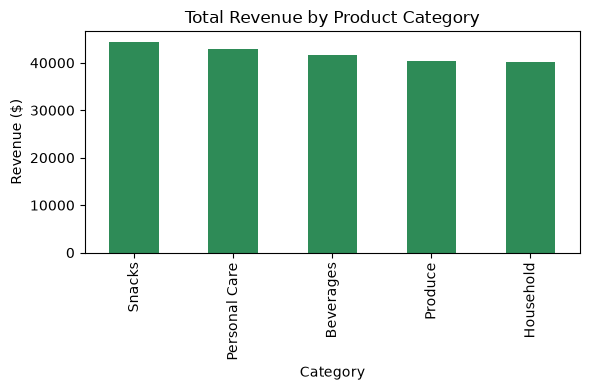

In [44]:
# Chart 1: Total revenue by product category
revenue_by_category = report_data.groupby("product_category")["dollar_sales"].sum().sort_values(ascending=False)

plt.figure(figsize=(6, 4))
revenue_by_category.plot(kind="bar", color="seagreen")
plt.title("Total Revenue by Product Category")
plt.xlabel("Category")
plt.ylabel("Revenue ($)")
plt.tight_layout()
plt.show()

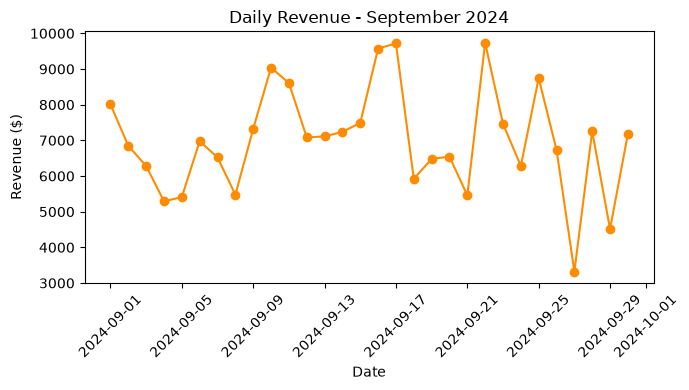

In [45]:
# Chart 2: Daily revenue trend across September
daily_revenue = report_data.groupby(report_data["date"].dt.date)["dollar_sales"].sum()

plt.figure(figsize=(7, 4))
daily_revenue.plot(kind="line", marker="o", color="darkorange")
plt.title("Daily Revenue - September 2024")
plt.xlabel("Date")
plt.ylabel("Revenue ($)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()